In [7]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams["figure.dpi"] = 140

RUN_DIR = Path("/home/zhaoy/CoFAI-my/CoFAI/runs/eval-rae/rae_mpc2_base_vbr_multirun_imagenet100")
BYPASS_DIR = Path("/home/zhaoy/CoFAI-my/CoFAI/runs/eval-rae/rae_bypass_base_reg4_imagenet100")
COMBINED_JSON = RUN_DIR / "imagenet_sel100_cls_results.json"
BYPASS_JSON = BYPASS_DIR / "imagenet_sel100_cls_results_1.json"
FILE_PREFIX = "imagenet_sel100_cls_results"

assert RUN_DIR.is_dir(), RUN_DIR
assert COMBINED_JSON.is_file(), COMBINED_JSON
assert BYPASS_JSON.is_file(), BYPASS_JSON

# RAE shallow MPC2 VBR multirun analysis

分析 `rae_shallow_mpc2_base_vbr_multirun_imagenet100` 这组 ImageNet-100 多 QP 结果，并用 `rae_bypass_base_reg4_imagenet100` 作为 bypass RAE baseline。

画图方式参考 `MPCompress/analyse.ipynb`：

- MPC2 VBR 多码率结果画成 rate-distortion 折线；
- bypass RAE 没有实际码率，画成平行于横轴的橙色虚线；
- 额外保留 bpp 拆分和 per-image 退化分析。

In [8]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def load_combined_results(path: Path) -> pd.DataFrame:
    data = load_json(path)
    results = data["results"]
    lengths = {
        len(v)
        for v in results.values()
        if isinstance(v, list)
    }
    assert len(lengths) == 1, f"inconsistent result lengths: {lengths}"
    n = lengths.pop()
    rows = []
    for i in range(n):
        row = {}
        for key, value in results.items():
            row[key] = value[i] if isinstance(value, list) else value
        rows.append(row)
    return pd.DataFrame(rows).sort_values("bpp").reset_index(drop=True)


def load_single_result(path: Path) -> dict:
    return load_json(path)["results"]


def load_record_results(run_dir: Path) -> pd.DataFrame:
    pattern = re.compile(rf"^{re.escape(FILE_PREFIX)}_(\d+)\.json$")
    rows = []
    for path in sorted(run_dir.glob(f"{FILE_PREFIX}_*.json")):
        match = pattern.match(path.name)
        if match is None:
            continue
        quality = int(match.group(1))
        data = load_json(path)
        for record in data.get("records", []):
            row = dict(record)
            row["quality"] = quality
            row["filename"] = Path(row["file"]).name
            rows.append(row)
    return pd.DataFrame(rows)

In [9]:
summary_df = load_combined_results(COMBINED_JSON)
bypass = load_single_result(BYPASS_JSON)
records_df = load_record_results(RUN_DIR)

print(f"summary points: {len(summary_df)}")
print(f"record rows: {len(records_df)}")
print("bypass:", {k: bypass[k] for k in ["PSNR", "MS-SSIM", "LPIPS-Alex"]})
summary_df

summary points: 9
record rows: 900
bypass: {'PSNR': 18.80062, 'MS-SSIM': 0.725526, 'LPIPS-Alex': 0.277769}


,quality,enc_time,dec_time,bpp,bpp_y,bpp_z,bpfp,PSNR,MS-SSIM,LPIPS-Alex
0,64,0.045247,0.045247,0.008196,0.007283,0.000913,0.002401,14.831725,0.458844,0.644512
1,56,0.054361,0.054361,0.013179,0.012137,0.001042,0.003860,15.435508,0.489287,0.556591
2,48,0.057959,0.057959,0.020417,0.019232,0.001185,0.005981,15.798008,0.514381,0.493956
3,40,0.058194,0.058194,0.029472,0.028151,0.001321,0.008632,15.983358,0.536898,0.456502
4,32,0.052804,0.052804,0.040598,0.039139,0.001459,0.011887,16.251318,0.552769,0.430871
5,24,0.054694,0.054694,0.053307,0.051667,0.001640,0.015598,16.414762,0.567956,0.416732
6,16,0.051879,0.051879,0.068635,0.066753,0.001882,0.020072,16.480303,0.576587,0.409024
7,8,0.039805,0.039805,0.085990,0.083766,0.002224,0.025136,16.617835,0.585570,0.404140
8,0,0.035717,0.035717,0.106704,0.103747,0.002957,0.031170,16.648138,0.590146,0.403764


In [10]:
display_cols = [
    "quality",
    "bpp",
    "bpp_y",
    "bpp_z",
    "bpfp",
    "PSNR",
    "MS-SSIM",
    "LPIPS-Alex",
    "enc_time",
    "dec_time",
]

bypass_row = {
    "quality": "bypass",
    "bpp": np.nan,
    "bpp_y": np.nan,
    "bpp_z": np.nan,
    "bpfp": np.nan,
    "PSNR": bypass["PSNR"],
    "MS-SSIM": bypass["MS-SSIM"],
    "LPIPS-Alex": bypass["LPIPS-Alex"],
    "enc_time": bypass["enc_time"],
    "dec_time": bypass["dec_time"],
}

table_df = pd.concat(
    [summary_df[display_cols].sort_values("quality"), pd.DataFrame([bypass_row])],
    ignore_index=True,
)

table_df.style.format({
    "bpp": "{:.6f}",
    "bpp_y": "{:.6f}",
    "bpp_z": "{:.6f}",
    "bpfp": "{:.6f}",
    "PSNR": "{:.3f}",
    "MS-SSIM": "{:.5f}",
    "LPIPS-Alex": "{:.5f}",
    "enc_time": "{:.4f}",
    "dec_time": "{:.4f}",
})

,quality,bpp,bpp_y,bpp_z,bpfp,PSNR,MS-SSIM,LPIPS-Alex,enc_time,dec_time
0,0,0.106704,0.103747,0.002957,0.031170,16.648,0.59015,0.40376,0.0357,0.0357
1,8,0.085990,0.083766,0.002224,0.025136,16.618,0.58557,0.40414,0.0398,0.0398
2,16,0.068635,0.066753,0.001882,0.020072,16.480,0.57659,0.40902,0.0519,0.0519
3,24,0.053307,0.051667,0.001640,0.015598,16.415,0.56796,0.41673,0.0547,0.0547
4,32,0.040598,0.039139,0.001459,0.011887,16.251,0.55277,0.43087,0.0528,0.0528
5,40,0.029472,0.028151,0.001321,0.008632,15.983,0.53690,0.45650,0.0582,0.0582
6,48,0.020417,0.019232,0.001185,0.005981,15.798,0.51438,0.49396,0.0580,0.0580
7,56,0.013179,0.012137,0.001042,0.003860,15.436,0.48929,0.55659,0.0544,0.0544
8,64,0.008196,0.007283,0.000913,0.002401,14.832,0.45884,0.64451,0.0452,0.0452
9,bypass,nan,nan,nan,nan,18.801,0.72553,0.27777,0.0130,0.0130


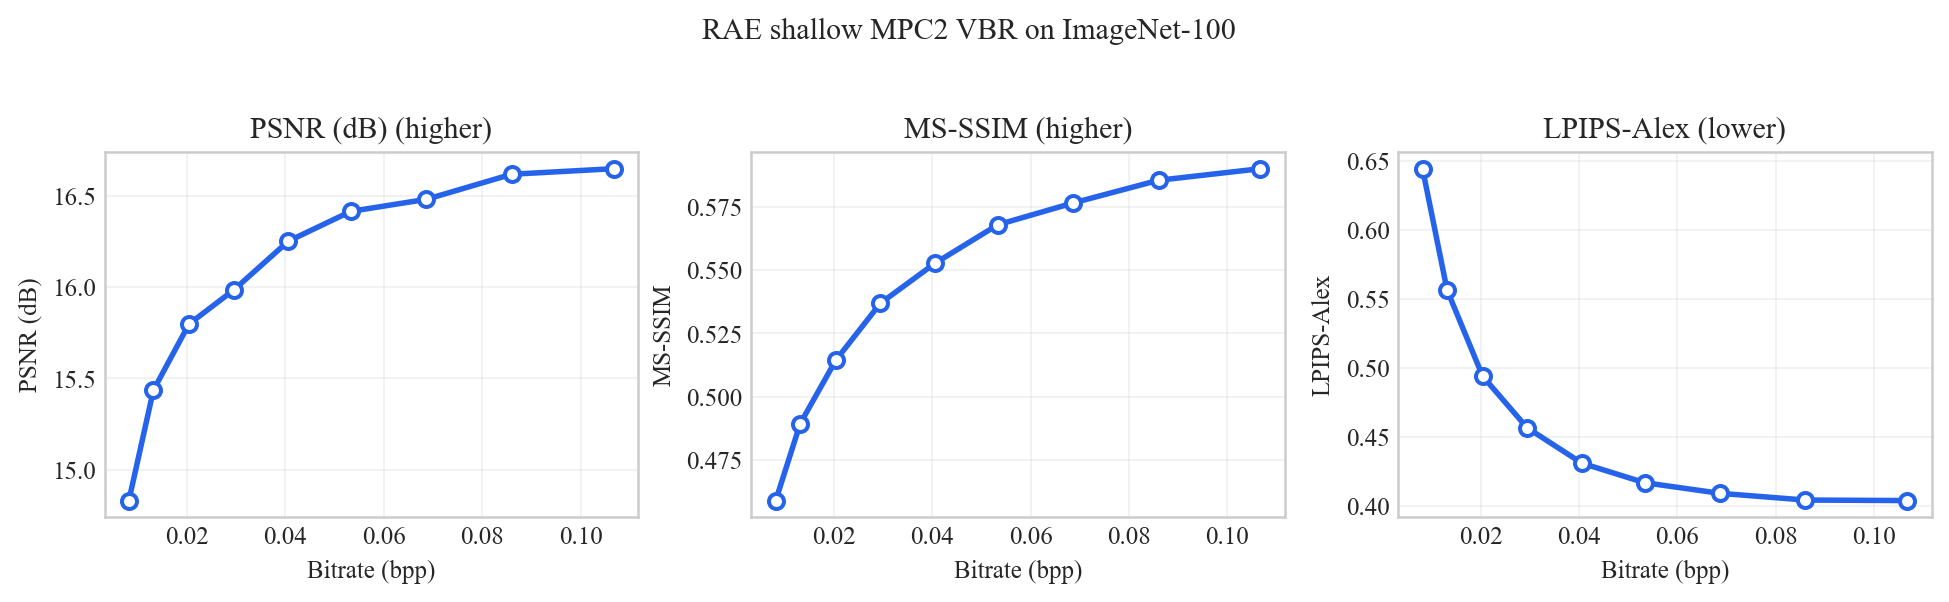

In [11]:
metrics = [
    ("PSNR", "PSNR (dB)", "higher"),
    ("MS-SSIM", "MS-SSIM", "higher"),
    ("LPIPS-Alex", "LPIPS-Alex", "lower"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), dpi=180)
main_color = "#2563EB"

for ax, (key, ylabel, direction) in zip(axes, metrics):
    ax.plot(
        summary_df["bpp"],
        summary_df[key],
        color=main_color,
        linewidth=2.2,
        marker="o",
        markersize=6,
        markerfacecolor="white",
        markeredgewidth=1.6,
    )

    
    ax.set_xlabel("Bitrate (bpp)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} ({direction})")
    ax.grid(True, alpha=0.25)

fig.suptitle("RAE shallow MPC2 VBR on ImageNet-100", y=1.03)
plt.tight_layout()
plt.savefig(RUN_DIR / "rd_curves.png", bbox_inches="tight")
plt.show()

## RD curves with bypass baseline

MPC2 VBR 结果按实际 `bpp` 画折线；bypass RAE 没有码率，因此按参考 notebook 的方式画成横向虚线。

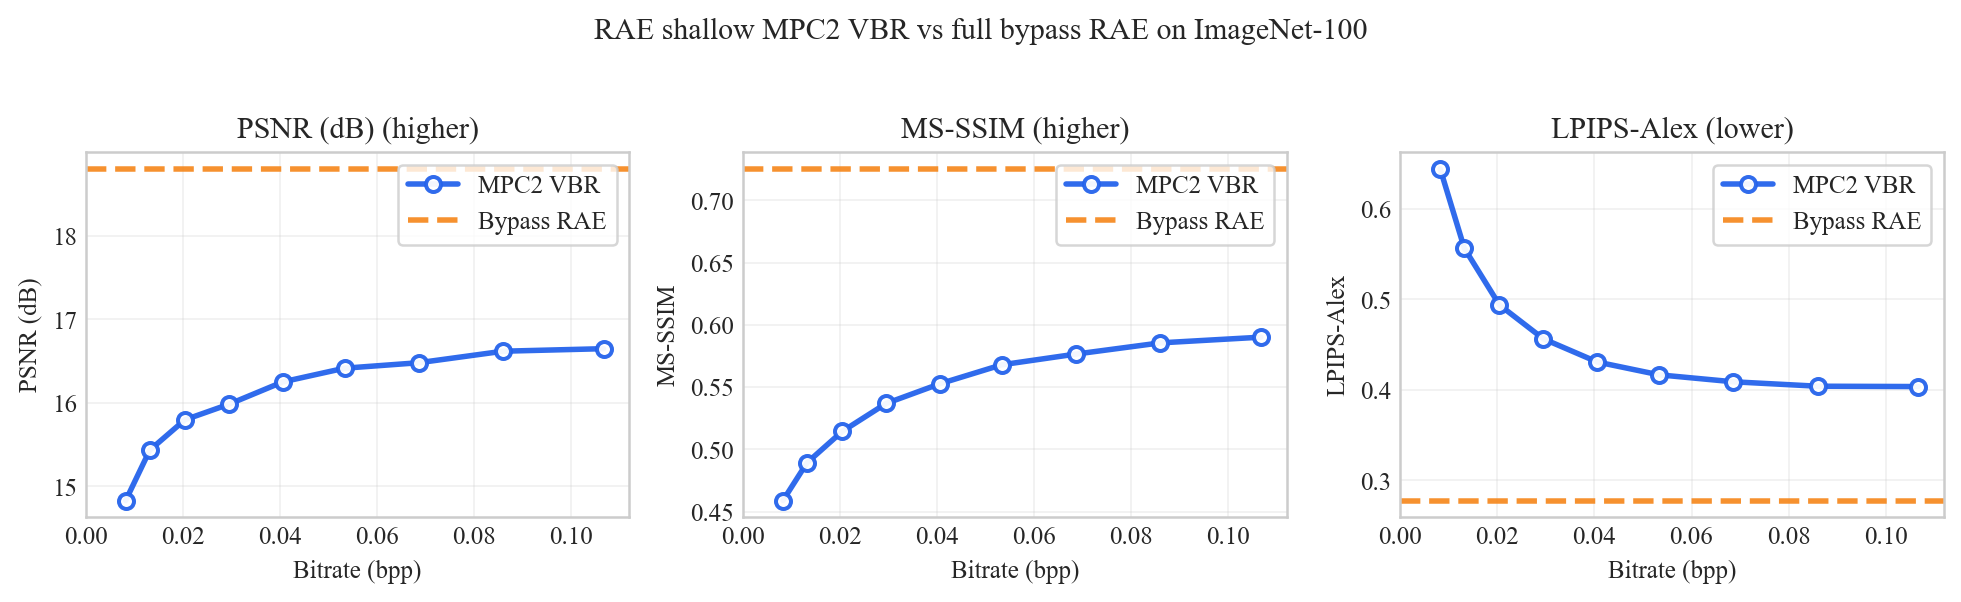

In [12]:
metrics = [
    ("PSNR", "PSNR (dB)", "higher"),
    ("MS-SSIM", "MS-SSIM", "higher"),
    ("LPIPS-Alex", "LPIPS-Alex", "lower"),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), dpi=180)
main_color = "#2563EB"
base_color = "#F58518"
x_min = 0.0
x_max = float(summary_df["bpp"].max()) * 1.05

for ax, (key, ylabel, direction) in zip(axes, metrics):
    ax.plot(
        summary_df["bpp"],
        summary_df[key],
        label="MPC2 VBR",
        color=main_color,
        linestyle="-",
        linewidth=2.2,
        marker="o",
        markersize=6,
        markerfacecolor="white",
        markeredgewidth=1.6,
        markeredgecolor=main_color,
        alpha=0.95,
        zorder=3,
    )
    ax.hlines(
        y=float(bypass[key]),
        xmin=x_min,
        xmax=x_max,
        label="Bypass RAE",
        colors=base_color,
        linestyles="--",
        linewidth=2.2,
        alpha=0.9,
        zorder=2,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Bitrate (bpp)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} ({direction})")
    ax.legend(frameon=True, loc="best")
    ax.grid(True, alpha=0.25)

fig.suptitle("RAE shallow MPC2 VBR vs full bypass RAE on ImageNet-100", y=1.03)
plt.tight_layout()
plt.savefig(RUN_DIR / "rd_curves_with_bypass.png", bbox_inches="tight")
plt.show()

In [13]:
# fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), dpi=180)

# summary_by_q = summary_df.sort_values("quality")
# axes[0].plot(summary_by_q["quality"], summary_by_q["bpp"], marker="o", label="total bpp")
# axes[0].plot(summary_by_q["quality"], summary_by_q["bpp_y"], marker="o", label="bpp_y")
# axes[0].plot(summary_by_q["quality"], summary_by_q["bpp_z"], marker="o", label="bpp_z")
# axes[0].set_xlabel("QP / quality")
# axes[0].set_ylabel("bpp")
# axes[0].set_title("Bit allocation")
# axes[0].legend()
# axes[0].grid(True, alpha=0.25)

# axes[1].plot(summary_by_q["quality"], summary_by_q["bpfp"], marker="o", color="#F58518")
# axes[1].set_xlabel("QP / quality")
# axes[1].set_ylabel("bpfp")
# axes[1].set_title("Bits per feature pixel")
# axes[1].grid(True, alpha=0.25)

# plt.tight_layout()
# plt.savefig(RUN_DIR / "bit_allocation.png", bbox_inches="tight")
# plt.show()

In [14]:
# Per-image degradation: compare the highest-bpp point with the lowest-bpp point.
# In this run, lower QP has higher bpp; we infer anchors from the actual data.
hi_q = int(summary_df.loc[summary_df["bpp"].idxmax(), "quality"])
lo_q = int(summary_df.loc[summary_df["bpp"].idxmin(), "quality"])
print(f"high-rate quality={hi_q}, low-rate quality={lo_q}")

wide = records_df.pivot(index="filename", columns="quality", values=["bpp", "PSNR", "MS-SSIM", "LPIPS-Alex"])
per_image = pd.DataFrame(index=wide.index)
per_image["bpp_high"] = wide[("bpp", hi_q)]
per_image["bpp_low"] = wide[("bpp", lo_q)]
per_image["psnr_high"] = wide[("PSNR", hi_q)]
per_image["psnr_low"] = wide[("PSNR", lo_q)]
per_image["msssim_high"] = wide[("MS-SSIM", hi_q)]
per_image["msssim_low"] = wide[("MS-SSIM", lo_q)]
per_image["lpips_high"] = wide[("LPIPS-Alex", hi_q)]
per_image["lpips_low"] = wide[("LPIPS-Alex", lo_q)]
per_image["delta_psnr"] = per_image["psnr_low"] - per_image["psnr_high"]
per_image["delta_msssim"] = per_image["msssim_low"] - per_image["msssim_high"]
per_image["delta_lpips"] = per_image["lpips_low"] - per_image["lpips_high"]
per_image["delta_bpp"] = per_image["bpp_low"] - per_image["bpp_high"]

per_image.sort_values("delta_lpips", ascending=False).head(15).style.format({
    "bpp_high": "{:.5f}",
    "bpp_low": "{:.5f}",
    "psnr_high": "{:.2f}",
    "psnr_low": "{:.2f}",
    "msssim_high": "{:.4f}",
    "msssim_low": "{:.4f}",
    "lpips_high": "{:.4f}",
    "lpips_low": "{:.4f}",
    "delta_psnr": "{:.2f}",
    "delta_msssim": "{:.4f}",
    "delta_lpips": "{:.4f}",
    "delta_bpp": "{:.5f}",
})

high-rate quality=0, low-rate quality=64


,bpp_high,bpp_low,psnr_high,psnr_low,msssim_high,msssim_low,lpips_high,lpips_low,delta_psnr,delta_msssim,delta_lpips,delta_bpp
filename,,,,,,,,,,,,
ILSVRC2012_val_00000258.JPEG,0.10390,0.00679,14.35,11.78,0.3849,0.2329,0.5901,1.0627,-2.56,-0.1520,0.4727,-0.09711
ILSVRC2012_val_00000921.JPEG,0.14345,0.00885,17.93,15.70,0.4973,0.3929,0.4619,0.9190,-2.23,-0.1044,0.4572,-0.13460
ILSVRC2012_val_00000107.JPEG,0.09810,0.00726,14.65,13.30,0.4439,0.2374,0.4611,0.9027,-1.35,-0.2066,0.4416,-0.09084
ILSVRC2012_val_00000299.JPEG,0.10054,0.00650,20.68,19.47,0.6209,0.6074,0.4341,0.8661,-1.21,-0.0135,0.4320,-0.09404
ILSVRC2012_val_00000319.JPEG,0.09470,0.00669,15.26,15.78,0.6287,0.4721,0.3467,0.7738,0.51,-0.1566,0.4271,-0.08801
ILSVRC2012_val_00000084.JPEG,0.11223,0.00881,15.59,13.89,0.4841,0.3044,0.4859,0.9040,-1.70,-0.1796,0.4181,-0.10343
ILSVRC2012_val_00000052.JPEG,0.11916,0.00848,18.52,12.60,0.7033,0.4668,0.3070,0.7153,-5.93,-0.2365,0.4083,-0.11068
ILSVRC2012_val_00000655.JPEG,0.10906,0.00760,12.87,11.39,0.3497,0.2259,0.4203,0.8151,-1.48,-0.1237,0.3948,-0.10146
ILSVRC2012_val_00001375.JPEG,0.11490,0.00752,13.22,12.94,0.3187,0.1769,0.6100,0.9859,-0.29,-0.1418,0.3759,-0.10737


In [15]:
# # Distribution plots over images at several QPs.
# plot_qualities = [q for q in [hi_q, 16, 32, 48, lo_q] if q in set(records_df["quality"])]
# plot_df = records_df[records_df["quality"].isin(plot_qualities)]

# fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), dpi=180)
# for ax, key, xlabel in zip(axes, ["PSNR", "MS-SSIM", "LPIPS-Alex"], ["PSNR (dB)", "MS-SSIM", "LPIPS-Alex"]):
#     for q in plot_qualities:
#         values = plot_df.loc[plot_df["quality"] == q, key].dropna().to_numpy(dtype=float)
#         ax.hist(values, bins=18, alpha=0.35, label=f"QP {q}")
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel("# images")
#     ax.set_title(f"Per-image {xlabel}")
#     ax.legend(fontsize=8)
#     ax.grid(True, alpha=0.2)

# plt.tight_layout()
# plt.savefig(RUN_DIR / "per_image_hist.png", bbox_inches="tight")
# plt.show()

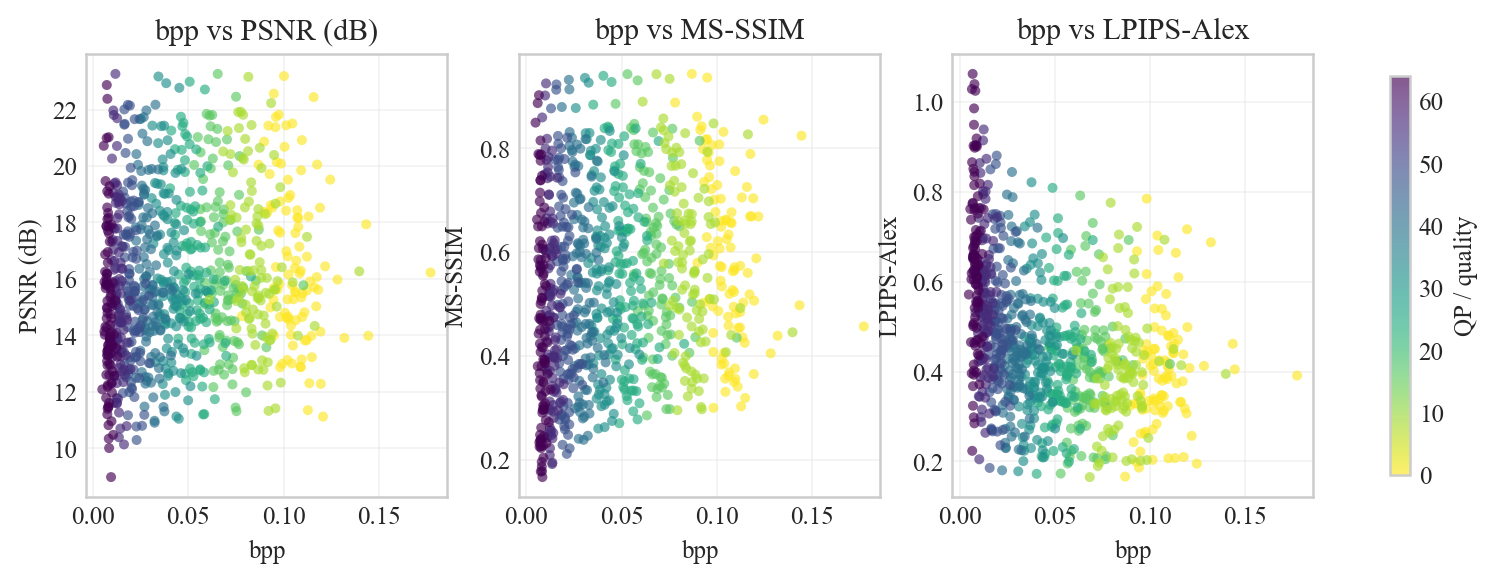

In [16]:
# Correlation between bitrate and quality at the image level.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), dpi=180)
for ax, key, ylabel in zip(axes, ["PSNR", "MS-SSIM", "LPIPS-Alex"], ["PSNR (dB)", "MS-SSIM", "LPIPS-Alex"]):
    scatter = ax.scatter(
        records_df["bpp"],
        records_df[key],
        c=records_df["quality"],
        s=16,
        cmap="viridis_r",
        alpha=0.65,
        edgecolors="none",
    )
    ax.set_xlabel("bpp")
    ax.set_ylabel(ylabel)
    ax.set_title(f"bpp vs {ylabel}")
    ax.grid(True, alpha=0.2)

cbar = fig.colorbar(scatter, ax=axes, shrink=0.9)
cbar.set_label("QP / quality")
plt.savefig(RUN_DIR / "per_image_scatter.png", bbox_inches="tight")
plt.show()

In [17]:
# Save compact CSVs for later comparison across runs.
summary_csv = RUN_DIR / "analysis_summary.csv"
per_image_csv = RUN_DIR / "analysis_per_image_delta.csv"

summary_df[display_cols].sort_values("quality").to_csv(summary_csv, index=False)
per_image.reset_index().sort_values("delta_lpips", ascending=False).to_csv(per_image_csv, index=False)

print(f"saved: {summary_csv}")
print(f"saved: {per_image_csv}")

saved: /home/zhaoy/CoFAI-my/CoFAI/runs/eval-rae/rae_mpc2_base_vbr_multirun_imagenet100/analysis_summary.csv
saved: /home/zhaoy/CoFAI-my/CoFAI/runs/eval-rae/rae_mpc2_base_vbr_multirun_imagenet100/analysis_per_image_delta.csv


## VITS decoder RD comparison

这里把两个新训出来的 `rae_dinov2_base_reg4_vits_512px` decoder 结果也加进来，和当前 base decoder 多码率结果、bypass RAE baseline 一起比较。注意：这两个 eval 结果如果是用 `model.pt` 跑的，只包含 decoder 权重，不包含训练时的 adapter。

In [19]:
COMPARE_RUNS = {
    "Base decoder": RUN_DIR,
    "VITS 260521-020918": Path("/home/zhaoy/CoFAI-my/CoFAI/runs/eval-rae/rae_shallow_mpc2_vits_260521_020918_imagenet100"),
    "VITS EMA 260522-062840": Path("/home/zhaoy/CoFAI-my/CoFAI/runs/eval-rae/rae_shallow_mpc2_vits_ema_260522_062840_imagenet100"),
}

compare_dfs = {}
for name, run_dir in COMPARE_RUNS.items():
    json_path = run_dir / "imagenet_sel100_cls_results.json"
    assert json_path.is_file(), json_path
    compare_dfs[name] = load_combined_results(json_path)

compare_summary = []
for name, df in compare_dfs.items():
    hi = df.loc[df["bpp"].idxmax()]
    lo = df.loc[df["bpp"].idxmin()]
    compare_summary.append({
        "run": name,
        "bpp_min": lo["bpp"],
        "bpp_max": hi["bpp"],
        "psnr_at_max_bpp": hi["PSNR"],
        "msssim_at_max_bpp": hi["MS-SSIM"],
        "lpips_at_max_bpp": hi["LPIPS-Alex"],
        "psnr_at_min_bpp": lo["PSNR"],
        "msssim_at_min_bpp": lo["MS-SSIM"],
        "lpips_at_min_bpp": lo["LPIPS-Alex"],
    })

pd.DataFrame(compare_summary).style.format({
    "bpp_min": "{:.6f}",
    "bpp_max": "{:.6f}",
    "psnr_at_max_bpp": "{:.3f}",
    "msssim_at_max_bpp": "{:.5f}",
    "lpips_at_max_bpp": "{:.5f}",
    "psnr_at_min_bpp": "{:.3f}",
    "msssim_at_min_bpp": "{:.5f}",
    "lpips_at_min_bpp": "{:.5f}",
})

,run,bpp_min,bpp_max,psnr_at_max_bpp,msssim_at_max_bpp,lpips_at_max_bpp,psnr_at_min_bpp,msssim_at_min_bpp,lpips_at_min_bpp
0,Base decoder,0.008196,0.106704,16.648,0.59015,0.40376,14.832,0.45884,0.64451
1,VITS 260521-020918,0.008196,0.106704,16.086,0.54121,0.76952,14.857,0.45105,0.80115
2,VITS EMA 260522-062840,0.008196,0.106704,16.285,0.53823,0.57224,14.934,0.44471,0.61765


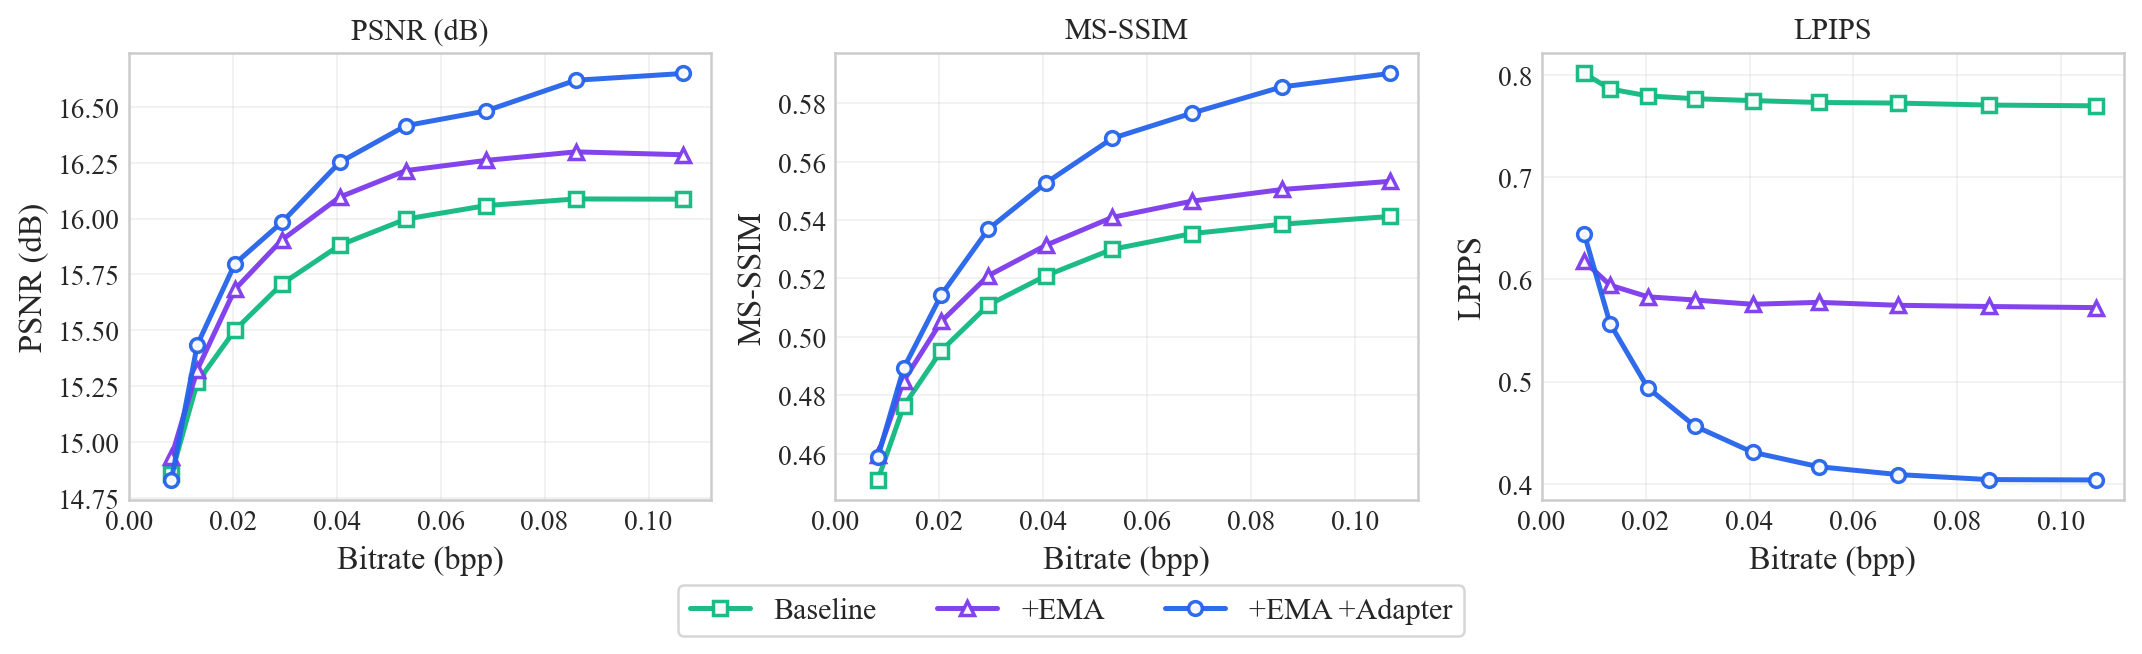

In [28]:
metrics = [
    ("PSNR", "PSNR (dB)", "higher"),
    ("MS-SSIM", "MS-SSIM", "higher"),
    ("LPIPS-Alex", "LPIPS", "lower"),
]

label_map = {
    "VITS 260521-020918": "Baseline",
    "VITS EMA 260522-062840": "+EMA",
    "Base decoder": "+EMA +Adapter",
}
plot_order = [
    "VITS 260521-020918",
    "VITS EMA 260522-062840",
    "Base decoder",
]
colors = {
    "Base decoder": "#2563EB",
    "VITS 260521-020918": "#10B981",
    "VITS EMA 260522-062840": "#7C3AED",
}
markers = {
    "Base decoder": "o",
    "VITS 260521-020918": "s",
    "VITS EMA 260522-062840": "^",
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), dpi=180)
label_fontsize = 13
tick_fontsize = 11
legend_fontsize = 12
x_min = 0.0
x_max = max(float(df["bpp"].max()) for df in compare_dfs.values()) * 1.05
for ax, (key, ylabel, direction) in zip(axes, metrics):
    for name in plot_order:
        df = compare_dfs[name]
        y_values = df[key].copy()
        if name == "VITS EMA 260522-062840" and key == "MS-SSIM":
            y_values = y_values + 0.015
        ax.plot(
            df["bpp"],
            y_values,
            label=label_map[name],
            color=colors[name],
            linestyle="-",
            linewidth=2.0,
            marker=markers[name],
            markersize=5.5,
            markerfacecolor="white",
            markeredgewidth=1.4,
            markeredgecolor=colors[name],
            alpha=0.95,
        )
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Bitrate (bpp)", fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    ax.set_title(f"{ylabel}")
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
    fontsize=legend_fontsize,
)
# fig.suptitle("RAE MPC2 VBR rate-distortion comparison on ImageNet-100", y=1.04)
plt.tight_layout()
plt.savefig(RUN_DIR / "rd_curves_vits_comparison.png", bbox_inches="tight")
plt.show()

In [27]:
RUN_DIR

PosixPath('/home/zhaoy/CoFAI-my/CoFAI/runs/eval-rae/rae_mpc2_base_vbr_multirun_imagenet100')